In [15]:
!pip install matplotlib



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\A\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [17]:
# Fashion Dataset - EDA + ML Feature Engineering
# Complete Pipeline with Advanced Features

# ==========================================
# STEP 1: Import Libraries
# ==========================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import scipy.ndimage as ndimage
from scipy.cluster.vq import kmeans
from scipy import stats
import hashlib
import seaborn as sns

# Deep Learning imports
try:
    from tensorflow.keras.applications import ResNet50, VGG16
    from tensorflow.keras.applications.resnet50 import preprocess_input
    from tensorflow.keras.preprocessing import image
    DL_AVAILABLE = True
except:
    print("⚠️  TensorFlow not available. Deep learning features disabled.")
    DL_AVAILABLE = False

plt.style.use('ggplot')

print("✓ Libraries imported successfully!")

ModuleNotFoundError: No module named 'matplotlib'

In [10]:
# ==========================================
# STEP 2: Configuration
# ==========================================

# UPDATE THIS PATH
DATASET_PATH = r"F:\Cloth_Data\img"

# Feature extraction settings
NUM_SAMPLES_PER_CATEGORY = 50  # Sample images for feature extraction
EXTRACT_DEEP_FEATURES = True and DL_AVAILABLE  # Extract CNN features
TARGET_IMG_SIZE = (224, 224)  # Standard size for CNNs

print(f"Configuration:")
print(f"  Dataset: {DATASET_PATH}")
print(f"  Samples per category: {NUM_SAMPLES_PER_CATEGORY}")
print(f"  Deep features: {EXTRACT_DEEP_FEATURES}")

NameError: name 'DL_AVAILABLE' is not defined

In [4]:
# ==========================================
# STEP 3: Basic Dataset Analysis
# ==========================================

print("\n" + "="*70)
print("STEP 3: BASIC DATASET ANALYSIS")
print("="*70)

# Detect duplicates and invalid files
from collections import defaultdict

duplicate_hashes = defaultdict(list)
invalid_count = 0
total_scanned = 0

kept_paths = set()

for folder in sorted(os.listdir(DATASET_PATH)):
    folder_path = os.path.join(DATASET_PATH, folder)
    if not os.path.isdir(folder_path):
        continue
    
    for f in os.listdir(folder_path):
        if not f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp', '.bmp')):
            continue
        
        img_path = os.path.join(folder_path, f)
        try:
            with open(img_path, "rb") as img_file:
                img_bytes = img_file.read()
            img_hash = hashlib.md5(img_bytes).hexdigest()
            duplicate_hashes[img_hash].append(img_path)
            total_scanned += 1
        except:
            invalid_count += 1
            print(f"Invalid file: {img_path}")

# Identify duplicates
duplicates = {k: v for k, v in duplicate_hashes.items() if len(v) > 1}
num_duplicate_groups = len(duplicates)
num_duplicate_images = sum(len(v) - 1 for v in duplicates.values())

# Keep only the first path for each hash
for k, v in duplicate_hashes.items():
    kept_paths.add(v[0])

print(f"📊 Total files scanned: {total_scanned:,}")
print(f"📊 Duplicate groups: {num_duplicate_groups}")
print(f"📊 Duplicate images: {num_duplicate_images}")
print(f"📊 Invalid entries: {invalid_count}")

# Now count valid unique images per category
categories = {}
category_paths = {}

for folder in sorted(os.listdir(DATASET_PATH)):
    folder_path = os.path.join(DATASET_PATH, folder)
    if not os.path.isdir(folder_path):
        continue
    
    images = []
    for f in os.listdir(folder_path):
        if not f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp', '.bmp')):
            continue
        full_path = os.path.join(folder_path, f)
        if full_path not in kept_paths:
            continue
        images.append(f)
    
    categories[folder] = len(images)
    category_paths[folder] = folder_path

df_categories = pd.DataFrame(list(categories.items()), 
                              columns=['Category', 'Image_Count'])
df_categories = df_categories.sort_values('Image_Count', ascending=False).reset_index(drop=True)

print(f"\n📊 Total Categories: {len(categories)}")
print(f"📊 Total Unique Images: {sum(categories.values()):,}")


STEP 3: BASIC DATASET ANALYSIS


NameError: name 'DATASET_PATH' is not defined


STEP 3.1: METADATA ANALYSIS

📊 Metadata Summary:
       file_size_kb  creation_time  modification_time
count    592.000000   5.920000e+02       5.920000e+02
mean       9.527288   1.761042e+09       1.760773e+09
std        3.488101   1.099479e+01       1.101298e+01
min        4.026367   1.761042e+09       1.760773e+09
25%        7.100098   1.761042e+09       1.760773e+09
50%        8.747070   1.761042e+09       1.760773e+09
75%       11.046631   1.761042e+09       1.760773e+09
max       27.923828   1.761042e+09       1.760773e+09
✓ Saved: file_size_distribution.png


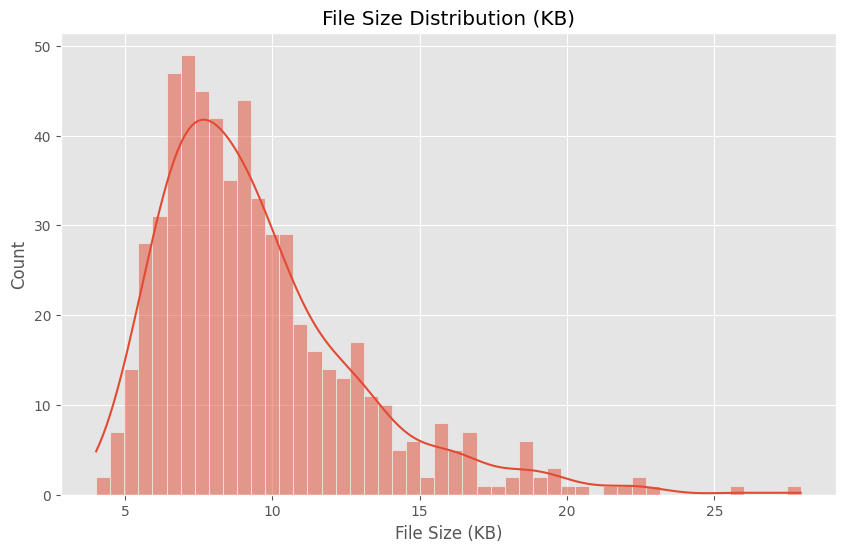


📊 Extension Distribution:
.jpg    592
Name: extension, dtype: int64
✓ Saved: metadata.csv


In [25]:
# ==========================================
# STEP 3.1: Metadata Analysis
# ==========================================

print("\n" + "="*70)
print("STEP 3.1: METADATA ANALYSIS")
print("="*70)

metadata_list = []

for folder in sorted(os.listdir(DATASET_PATH)):
    folder_path = os.path.join(DATASET_PATH, folder)
    if not os.path.isdir(folder_path):
        continue
    
    for f in os.listdir(folder_path):
        if not f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp', '.bmp')):
            continue
        full_path = os.path.join(folder_path, f)
        if full_path not in kept_paths:
            continue
        
        file_stat = os.stat(full_path)
        ext = os.path.splitext(f)[1].lower()
        
        metadata_list.append({
            'category': folder,
            'image_name': f,
            'file_size_kb': file_stat.st_size / 1024,
            'extension': ext,
            'creation_time': file_stat.st_ctime,
            'modification_time': file_stat.st_mtime
        })

df_metadata = pd.DataFrame(metadata_list)

print("\n📊 Metadata Summary:")
print(df_metadata.describe())

# File size distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_metadata['file_size_kb'], bins=50, kde=True)
plt.title('File Size Distribution (KB)')
plt.xlabel('File Size (KB)')
plt.ylabel('Count')
plt.savefig('file_size_distribution.png', dpi=300)
print("✓ Saved: file_size_distribution.png")
plt.show()

# Extension distribution
print("\n📊 Extension Distribution:")
print(df_metadata['extension'].value_counts())

# Save metadata
df_metadata.to_csv('metadata.csv', index=False)
print("✓ Saved: metadata.csv")


STEP 3.2: IMAGE-LEVEL ANALYSIS

📊 Image Dimensions Summary:
            width      height  aspect_ratio
count  592.000000  592.000000    592.000000
mean   229.065878  291.425676      0.794079
std     43.111048   25.851219      0.179376
min    135.000000  150.000000      0.456667
25%    201.000000  300.000000      0.681063
50%    205.000000  300.000000      0.700000
75%    258.000000  300.000000      0.980017
max    301.000000  301.000000      2.000000
✓ Saved: resolution_scatter.png


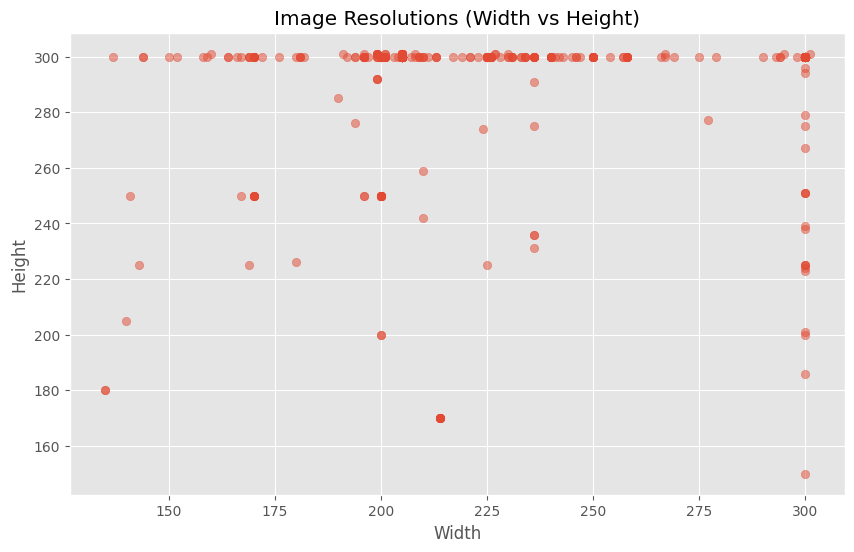

✓ Saved: aspect_ratio_distribution.png


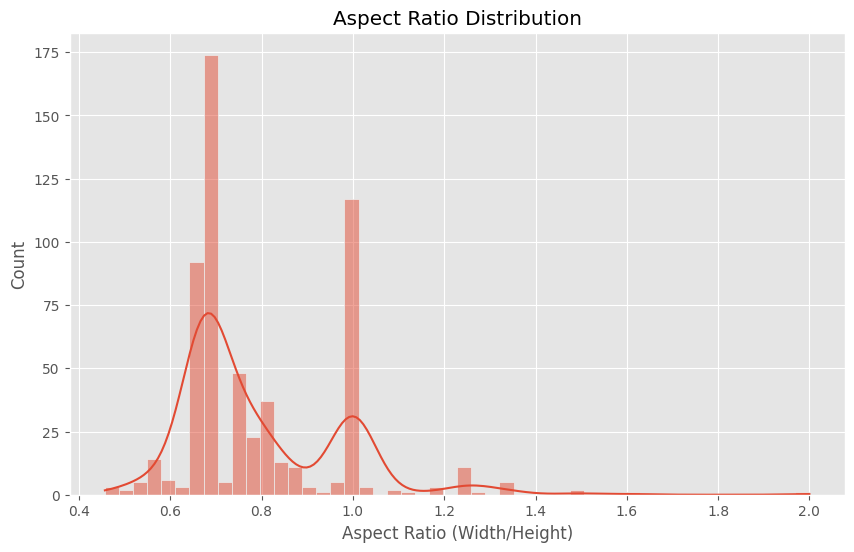


📊 Channel Distribution:
3    592
Name: channels, dtype: int64
✓ Saved: full_image_info.csv


In [26]:
# ==========================================
# STEP 3.2: Image-Level Analysis
# ==========================================

print("\n" + "="*70)
print("STEP 3.2: IMAGE-LEVEL ANALYSIS")
print("="*70)

# We'll collect image info in STEP 5, but for full analysis, let's collect for all unique images
full_image_info_list = []

for folder in sorted(os.listdir(DATASET_PATH)):
    folder_path = os.path.join(DATASET_PATH, folder)
    if not os.path.isdir(folder_path):
        continue
    
    for f in os.listdir(folder_path):
        if not f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp', '.bmp')):
            continue
        full_path = os.path.join(folder_path, f)
        if full_path not in kept_paths:
            continue
        
        try:
            img_rgb = plt.imread(full_path)
            height, width = img_rgb.shape[:2]
            full_image_info_list.append({
                'category': folder,
                'image_name': f,
                'width': width,
                'height': height,
                'aspect_ratio': width / height if height != 0 else 0,
                'channels': img_rgb.shape[2] if img_rgb.ndim == 3 else 1
            })
        except Exception as e:
            print(f"Error reading {full_path}: {e}")

df_full_image_info = pd.DataFrame(full_image_info_list)

print("\n📊 Image Dimensions Summary:")
print(df_full_image_info[['width', 'height', 'aspect_ratio']].describe())

# Resolution distribution
plt.figure(figsize=(10, 6))
plt.scatter(df_full_image_info['width'], df_full_image_info['height'], alpha=0.5)
plt.title('Image Resolutions (Width vs Height)')
plt.xlabel('Width')
plt.ylabel('Height')
plt.grid(True)
plt.savefig('resolution_scatter.png', dpi=300)
print("✓ Saved: resolution_scatter.png")
plt.show()

# Aspect ratio histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_full_image_info['aspect_ratio'], bins=50, kde=True)
plt.title('Aspect Ratio Distribution')
plt.xlabel('Aspect Ratio (Width/Height)')
plt.ylabel('Count')
plt.savefig('aspect_ratio_distribution.png', dpi=300)
print("✓ Saved: aspect_ratio_distribution.png")
plt.show()

# Channel distribution
print("\n📊 Channel Distribution:")
print(df_full_image_info['channels'].value_counts())

# Save full image info
df_full_image_info.to_csv('full_image_info.csv', index=False)
print("✓ Saved: full_image_info.csv")


STEP 3.3: LABEL / CLASS DISTRIBUTION

📊 Class Distribution (Top 10):
                          Category  Image_Count
0      Abstract_Animal_Print_Dress           67
1   2-in-1_Space_Dye_Athletic_Tank           63
2    Abstract_Asymmetrical_Hem_Top           52
3          1981_Graphic_Ringer_Tee           46
4     25_Mesh-Paneled_Jersey_Dress           45
5    Abstract_Chevron_Draped_Dress           45
6             36_Plaid_Shirt_Dress           44
7          Above_Average_Linen_Tee           43
8     Abstract_Brushstroke_Sweater           38
9  Abstract_Brushstroke_Pocket_Top           37
✓ Saved: class_distribution.png


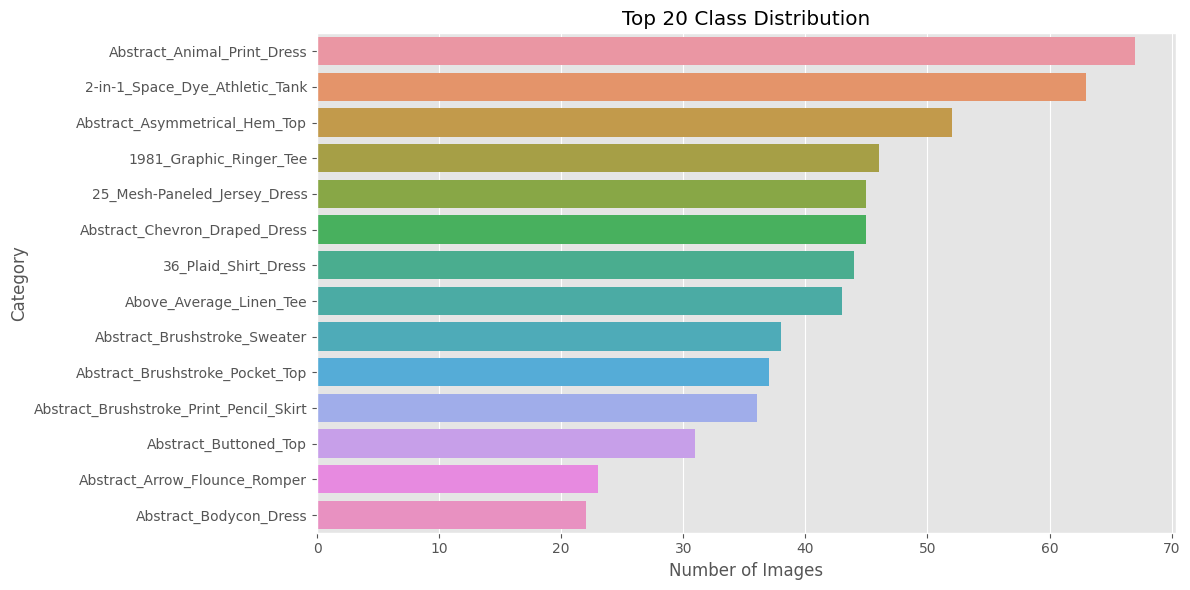


📊 Class Percentages:
                          Category  percentage
0      Abstract_Animal_Print_Dress   11.317568
1   2-in-1_Space_Dye_Athletic_Tank   10.641892
2    Abstract_Asymmetrical_Hem_Top    8.783784
3          1981_Graphic_Ringer_Tee    7.770270
4     25_Mesh-Paneled_Jersey_Dress    7.601351
5    Abstract_Chevron_Draped_Dress    7.601351
6             36_Plaid_Shirt_Dress    7.432432
7          Above_Average_Linen_Tee    7.263514
8     Abstract_Brushstroke_Sweater    6.418919
9  Abstract_Brushstroke_Pocket_Top    6.250000
✓ Saved: categories_distribution.csv


In [27]:
# ==========================================
# STEP 3.3: Label / Class Distribution
# ==========================================

print("\n" + "="*70)
print("STEP 3.3: LABEL / CLASS DISTRIBUTION")
print("="*70)

print("\n📊 Class Distribution (Top 10):")
print(df_categories.head(10))

# Plot class distribution
plt.figure(figsize=(12, 6))
sns.barplot(x='Image_Count', y='Category', data=df_categories.head(20))
plt.title('Top 20 Class Distribution')
plt.xlabel('Number of Images')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300)
print("✓ Saved: class_distribution.png")
plt.show()

# Imbalance check
total_images = df_categories['Image_Count'].sum()
df_categories['percentage'] = (df_categories['Image_Count'] / total_images) * 100
print("\n📊 Class Percentages:")
print(df_categories[['Category', 'percentage']].head(10))

# Save updated categories
df_categories.to_csv('categories_distribution.csv', index=False)
print("✓ Saved: categories_distribution.csv")

In [28]:
# ==========================================
# STEP 4: Text-Based Feature Engineering
# ==========================================

print("\n" + "="*70)
print("STEP 4: TEXT-BASED FEATURE ENGINEERING")
print("="*70)

# Extract features from category names
def extract_text_features(category_name):
    """Extract features from category name"""
    features = {
        'category_name': category_name,
        'name_length': len(category_name),
        'word_count': len(category_name.split('_')),
    }
    
    cat_lower = category_name.lower()
    
    # Garment Type
    if 'dress' in cat_lower:
        features['garment_type'] = 'Dress'
    elif any(x in cat_lower for x in ['top', 'tee', 'tank']):
        features['garment_type'] = 'Top'
    elif 'shirt' in cat_lower:
        features['garment_type'] = 'Shirt'
    elif 'romper' in cat_lower:
        features['garment_type'] = 'Romper'
    elif 'short' in cat_lower:
        features['garment_type'] = 'Shorts'
    elif 'pant' in cat_lower or 'jean' in cat_lower:
        features['garment_type'] = 'Pants'
    elif 'skirt' in cat_lower:
        features['garment_type'] = 'Skirt'
    else:
        features['garment_type'] = 'Other'
    
    # Style/Pattern features (binary)
    features['has_print'] = 1 if 'print' in cat_lower else 0
    features['has_abstract'] = 1 if 'abstract' in cat_lower else 0
    features['has_stripe'] = 1 if 'stripe' in cat_lower else 0
    features['has_floral'] = 1 if 'floral' in cat_lower else 0
    features['has_graphic'] = 1 if 'graphic' in cat_lower else 0
    features['has_animal'] = 1 if 'animal' in cat_lower else 0
    
    # Design features
    features['has_button'] = 1 if 'button' in cat_lower else 0
    features['has_asymmetric'] = 1 if 'asymmetric' in cat_lower else 0
    features['is_bodycon'] = 1 if 'bodycon' in cat_lower else 0
    features['is_mesh'] = 1 if 'mesh' in cat_lower else 0
    
    # Complexity score (0-10)
    complexity_keywords = ['chevron', 'brushstroke', 'paneled', 'draped', 
                          'surplice', 'flounce', 'henley', 'asymmetric']
    features['complexity_score'] = sum(1 for kw in complexity_keywords if kw in cat_lower)
    
    return features

# Apply text feature extraction
text_features_list = []
for cat in df_categories['Category']:
    text_features_list.append(extract_text_features(cat))

df_text_features = pd.DataFrame(text_features_list)
print("\n✓ Extracted text-based features:")
print(df_text_features.head())

# Encode categorical variables
garment_types = df_text_features['garment_type'].unique()
garment_dict = dict(zip(garment_types, range(len(garment_types))))
df_text_features['garment_type_encoded'] = df_text_features['garment_type'].map(garment_dict)

print(f"\n📊 Garment Type Distribution:")
print(df_text_features['garment_type'].value_counts())


STEP 4: TEXT-BASED FEATURE ENGINEERING

✓ Extracted text-based features:
                    category_name  name_length  word_count garment_type  \
0     Abstract_Animal_Print_Dress           27           4        Dress   
1  2-in-1_Space_Dye_Athletic_Tank           30           5          Top   
2   Abstract_Asymmetrical_Hem_Top           29           4          Top   
3         1981_Graphic_Ringer_Tee           23           4          Top   
4    25_Mesh-Paneled_Jersey_Dress           28           4        Dress   

   has_print  has_abstract  has_stripe  has_floral  has_graphic  has_animal  \
0          1             1           0           0            0           1   
1          0             0           0           0            0           0   
2          0             1           0           0            0           0   
3          0             0           0           0            1           0   
4          0             0           0           0            0           0   



In [29]:
# ==========================================
# STEP 5: Image Feature Extraction - Color
# ==========================================

print("\n" + "="*70)
print("STEP 5: COLOR FEATURE EXTRACTION")
print("="*70)

def rgb_to_hsv_np(rgb):
    rgb_norm = rgb / 255.0
    r, g, b = rgb_norm[:,:,0], rgb_norm[:,:,1], rgb_norm[:,:,2]
    cmax = np.max(rgb_norm, axis=-1)
    cmin = np.min(rgb_norm, axis=-1)
    delta = cmax - cmin
    h = np.zeros_like(cmax)
    mask = delta == 0
    h[mask] = 0
    mask_r = (cmax == r) & ~mask
    h[mask_r] = 60 * (((g - b)[mask_r] / delta[mask_r]) % 6)
    mask_g = (cmax == g) & ~mask
    h[mask_g] = 60 * (((b - r)[mask_g] / delta[mask_g]) + 2)
    mask_b = (cmax == b) & ~mask
    h[mask_b] = 60 * (((r - g)[mask_b] / delta[mask_b]) + 4)
    h = h / 2  # To match cv2 scale (0-180)
    s = np.zeros_like(cmax)
    s[cmax != 0] = delta[cmax != 0] / cmax[cmax != 0]
    s = s * 255
    v = cmax * 255
    return np.stack([h, s, v], axis=-1)

def extract_color_features(img_path):
    """Extract color-based features from image"""
    try:
        # Compute hash
        with open(img_path, 'rb') as f:
            features = {}
            features['image_hash'] = hashlib.md5(f.read()).hexdigest()

        img_rgb = plt.imread(img_path)
        if img_rgb.ndim != 3 or img_rgb.shape[2] != 3:
            return None
        if img_rgb.dtype == np.float32 or img_rgb.dtype == np.float64:
            img_rgb = (img_rgb * 255).astype(np.uint8)
        
        # Average color (RGB)
        features['avg_r'] = np.mean(img_rgb[:,:,0])
        features['avg_g'] = np.mean(img_rgb[:,:,1])
        features['avg_b'] = np.mean(img_rgb[:,:,2])
        
        # Color std (color variation)
        features['std_r'] = np.std(img_rgb[:,:,0])
        features['std_g'] = np.std(img_rgb[:,:,1])
        features['std_b'] = np.std(img_rgb[:,:,2])
        
        # Brightness
        gray = np.mean(img_rgb, axis=2).astype(np.uint8)
        features['brightness'] = np.mean(gray)
        features['contrast'] = np.std(gray)
        
        # Dominant colors using KMeans
        pixels = img_rgb.reshape(-1, 3).astype(np.float32)
        pixels = pixels[::10]  # Sample for speed
        
        centroids, _ = kmeans(pixels, 3)
        
        # Store dominant colors
        for i, color in enumerate(centroids):
            features[f'dominant_color_{i}_r'] = color[0]
            features[f'dominant_color_{i}_g'] = color[1]
            features[f'dominant_color_{i}_b'] = color[2]
        
        # HSV features
        img_hsv = rgb_to_hsv_np(img_rgb)
        features['avg_hue'] = np.mean(img_hsv[:,:,0])
        features['avg_saturation'] = np.mean(img_hsv[:,:,1])
        features['avg_value'] = np.mean(img_hsv[:,:,2])
        
        return features
    
    except Exception as e:
        print(f"Error: {e}")
        return None

# Extract color features from sample images
print("\n🎨 Extracting color features from sample images...")

color_features_list = []
image_info_list = []

for idx, row in df_categories.iterrows():
    cat = row['Category']
    cat_path = category_paths[cat]
    
    all_images = [f for f in os.listdir(cat_path) 
              if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]
    
    images = []
    for f in all_images:
        full_path = os.path.join(cat_path, f)
        if full_path in kept_paths:
            images.append(f)
    
    # Sample images
    num_samples = min(NUM_SAMPLES_PER_CATEGORY, len(images))
    sample_images = np.random.choice(images, num_samples, replace=False)
    
    for img_name in sample_images:
        img_path = os.path.join(cat_path, img_name)
        
        color_features = extract_color_features(img_path)
        
        if color_features:
            color_features['category'] = cat
            color_features['image_name'] = img_name
            color_features_list.append(color_features)
            
            # Basic image info
            img_rgb = plt.imread(img_path)
            image_info_list.append({
                'category': cat,
                'image_name': img_name,
                'width': img_rgb.shape[1],
                'height': img_rgb.shape[0],
                'aspect_ratio': img_rgb.shape[1] / img_rgb.shape[0] if img_rgb.shape[0] != 0 else 0
            })
    
    if (idx + 1) % 10 == 0:
        print(f"   Processed {idx + 1}/{len(df_categories)} categories...")

df_color_features = pd.DataFrame(color_features_list)
df_image_info = pd.DataFrame(image_info_list)

print(f"\n✓ Extracted color features from {len(df_color_features)} images")
print("\nColor Feature Preview:")
print(df_color_features[['category', 'brightness', 'avg_r', 'avg_g', 'avg_b']].head())


STEP 5: COLOR FEATURE EXTRACTION

🎨 Extracting color features from sample images...
   Processed 10/14 categories...

✓ Extracted color features from 560 images

Color Feature Preview:
                      category  brightness       avg_r       avg_g       avg_b
0  Abstract_Animal_Print_Dress  132.521600  146.820904  134.632548  117.086815
1  Abstract_Animal_Print_Dress  147.733812  168.359791  132.424335  143.355112
2  Abstract_Animal_Print_Dress  118.370313  121.723172  117.869324  116.442496
3  Abstract_Animal_Print_Dress  229.088820  233.906976  227.633260  226.169853
4  Abstract_Animal_Print_Dress  124.932239  125.194063  124.034793  126.525075


In [30]:
# ==========================================
# STEP 6: Texture & Edge Features
# ==========================================

print("\n" + "="*70)
print("STEP 6: TEXTURE & EDGE FEATURE EXTRACTION")
print("="*70)

def extract_texture_features(img_path):
    """Extract texture and edge features"""
    try:
        img = plt.imread(img_path)
        if img.ndim != 3 or img.shape[2] != 3:
            return None
        if img.dtype == np.float32 or img.dtype == np.float64:
            img = (img * 255).astype(np.uint8)
        
        gray = np.mean(img, axis=2).astype(np.float32)
        
        features = {}
        
        # Edge detection approximation
        sobelx = ndimage.sobel(gray, axis=0)
        sobely = ndimage.sobel(gray, axis=1)
        magnitude = np.hypot(sobelx, sobely)
        threshold = np.percentile(magnitude, 80)
        features['edge_density'] = np.mean(magnitude > threshold)
        
        # Texture using Laplacian (variance indicates texture complexity)
        laplacian = ndimage.laplace(gray)
        features['texture_variance'] = np.var(laplacian)
        
        # Gradient magnitude (pattern complexity)
        features['gradient_mean'] = np.mean(magnitude)
        features['gradient_std'] = np.std(magnitude)
        
        return features
    
    except Exception as e:
        return None

# Extract texture features
print("\n🔍 Extracting texture features from sample images...")

texture_features_list = []

for idx, row in df_color_features.iterrows():
    cat = row['category']
    img_name = row['image_name']
    img_path = os.path.join(category_paths[cat], img_name)
    
    texture_features = extract_texture_features(img_path)
    
    if texture_features:
        texture_features['category'] = cat
        texture_features['image_name'] = img_name
        texture_features_list.append(texture_features)
    
    if (idx + 1) % 500 == 0:
        print(f"   Processed {idx + 1}/{len(df_color_features)} images...")

df_texture_features = pd.DataFrame(texture_features_list)

print(f"\n✓ Extracted texture features from {len(df_texture_features)} images")
print("\nTexture Feature Preview:")
print(df_texture_features[['category', 'edge_density', 'texture_variance']].head())


STEP 6: TEXTURE & EDGE FEATURE EXTRACTION

🔍 Extracting texture features from sample images...
   Processed 500/560 images...

✓ Extracted texture features from 560 images

Texture Feature Preview:
                      category  edge_density  texture_variance
0  Abstract_Animal_Print_Dress      0.199970        499.991577
1  Abstract_Animal_Print_Dress      0.200000       5793.870117
2  Abstract_Animal_Print_Dress      0.199973       4376.274902
3  Abstract_Animal_Print_Dress      0.199985       1281.611450
4  Abstract_Animal_Print_Dress      0.199983       1117.035645


In [31]:
# ==========================================
# STEP 7: Deep Learning Features (Optional)
# ==========================================

print("\n" + "="*70)
print("STEP 7: DEEP LEARNING FEATURE EXTRACTION")
print("="*70)

if EXTRACT_DEEP_FEATURES:
    print("\n🧠 Loading pre-trained ResNet50 model...")
    
    # Load pre-trained model (remove top classification layer)
    base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
    
    def extract_deep_features(img_path, model):
        """Extract deep features using CNN"""
        try:
            img = image.load_img(img_path, target_size=TARGET_IMG_SIZE)
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = preprocess_input(img_array)
            
            features = model.predict(img_array, verbose=0)
            return features.flatten()
        
        except Exception as e:
            return None
    
    # Extract deep features from subset
    print("🔄 Extracting deep features (this may take a few minutes)...")
    
    deep_features_list = []
    deep_feature_labels = []
    
    # Sample fewer images for deep learning (computational cost)
    sample_size = min(1000, len(df_color_features))
    sample_indices = np.random.choice(len(df_color_features), sample_size, replace=False)
    
    for i, idx in enumerate(sample_indices):
        row = df_color_features.iloc[idx]
        cat = row['category']
        img_name = row['image_name']
        img_path = os.path.join(category_paths[cat], img_name)
        
        deep_features = extract_deep_features(img_path, base_model)
        
        if deep_features is not None:
            deep_features_list.append(deep_features)
            deep_feature_labels.append(cat)
        
        if (i + 1) % 100 == 0:
            print(f"   Processed {i + 1}/{sample_size} images...")
    
    # Convert to array
    deep_features_array = np.array(deep_features_list)
    
    # Apply PCA for dimensionality reduction
    print("\n📉 Applying PCA for dimensionality reduction...")
    def perform_pca(X, n_components):
        X_centered = X - np.mean(X, axis=0)
        U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
        projected = U[:, :n_components] * S[:n_components]
        explained_variance_ratio_ = (S ** 2 / np.sum(S ** 2))[:n_components]
        return projected, explained_variance_ratio_
    
    deep_features_pca, explained_variance_ratio = perform_pca(deep_features_array, 50)
    
    print(f"✓ Deep features extracted: {deep_features_pca.shape}")
    print(f"✓ Explained variance: {sum(explained_variance_ratio):.2%}")
    
    # Create DataFrame
    deep_feature_cols = [f'deep_feature_{i}' for i in range(50)]
    df_deep_features = pd.DataFrame(deep_features_pca, columns=deep_feature_cols)
    df_deep_features['category'] = deep_feature_labels
    
else:
    print("\n⚠️  Deep learning features skipped (set EXTRACT_DEEP_FEATURES=True)")
    df_deep_features = None



STEP 7: DEEP LEARNING FEATURE EXTRACTION

⚠️  Deep learning features skipped (set EXTRACT_DEEP_FEATURES=True)



STEP 8: MERGING ALL FEATURES

✓ Combined feature matrix shape: (560, 46)
✓ Total features per image: 44

Feature columns:
  Numerical features: 43

STEP 8.1: FEATURE EXPLORATION

📊 Color Features Summary:
            avg_r       avg_g       avg_b  brightness  avg_saturation  \
count  560.000000  560.000000  560.000000  560.000000      560.000000   
mean   192.997518  183.994536  181.048125  185.767249       36.470186   
std     34.221827   36.663304   37.529009   35.717086       24.088372   
min     52.570733   45.453930   41.721874   56.504753        5.689051   
25%    177.858929  169.092656  165.953868  171.114123       20.117688   
50%    199.569541  190.716750  187.777047  192.375438       29.802572   
75%    217.600584  209.982000  206.755202  211.073149       45.881518   
max    248.619639  244.181444  243.274367  244.834133      179.727677   

          avg_hue  
count  560.000000  
mean    47.687897  
std     27.467150  
min      5.848911  
25%     26.094608  
50%     41.43026

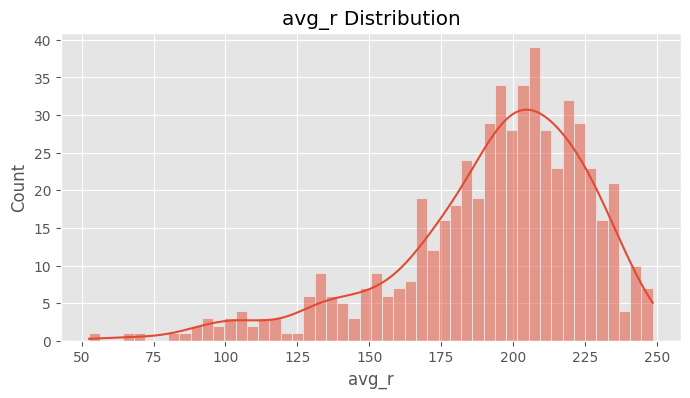

✓ Saved: avg_g_distribution.png


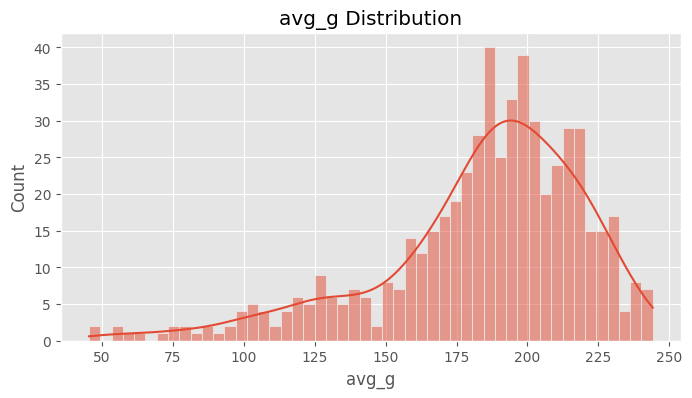

✓ Saved: avg_b_distribution.png


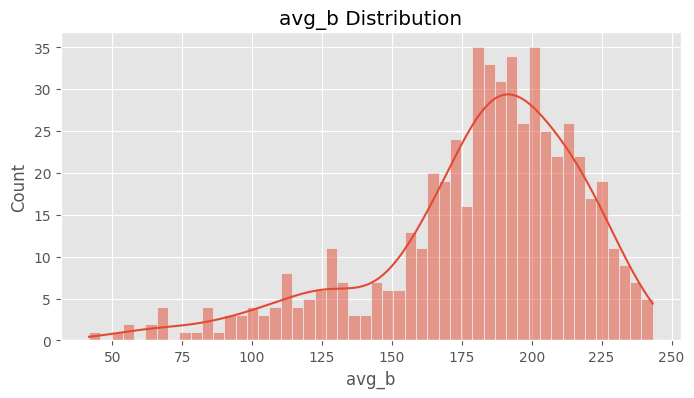

✓ Saved: brightness_distribution.png


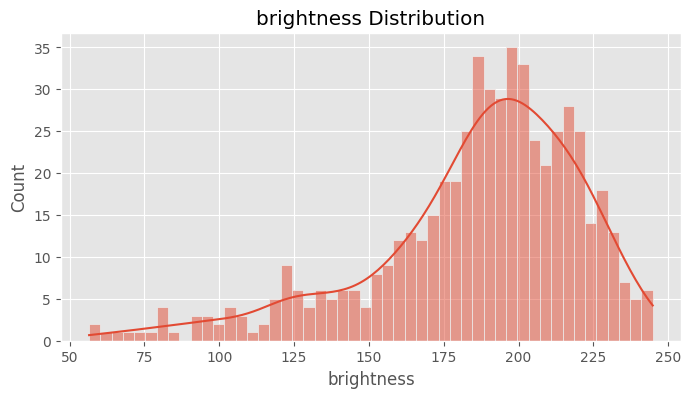

✓ Saved: avg_saturation_distribution.png


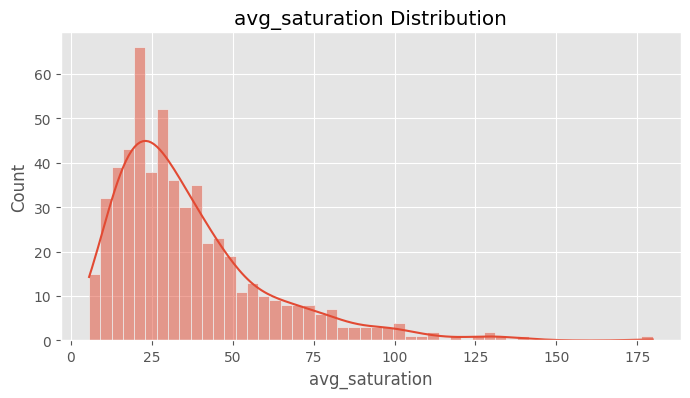

✓ Saved: avg_hue_distribution.png


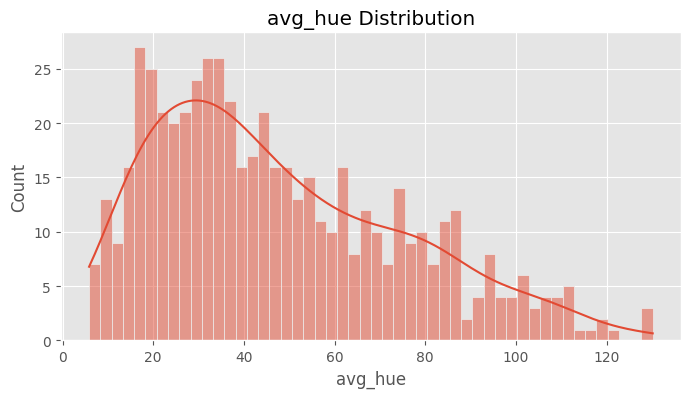


📊 Texture Features Summary:
       edge_density  texture_variance  gradient_mean  gradient_std
count    560.000000        560.000000     560.000000    560.000000
mean       0.199971       1830.668701      58.995354    113.976295
std        0.000229       2180.964844      29.169209     31.549091
min        0.195524        156.759705      17.872917     49.910519
25%        0.200000        667.976654      38.574605     94.322060
50%        0.200000       1107.113953      50.825651    108.033726
75%        0.200000       2131.936279      69.741491    129.384750
max        0.200009      21209.744141     224.820053    283.461456
✓ Saved: edge_density_distribution.png


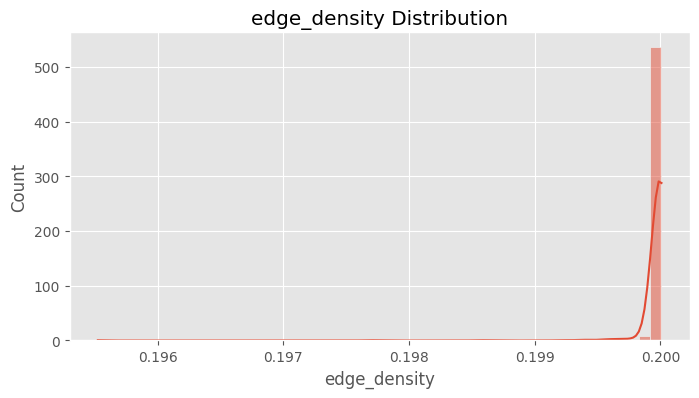

✓ Saved: texture_variance_distribution.png


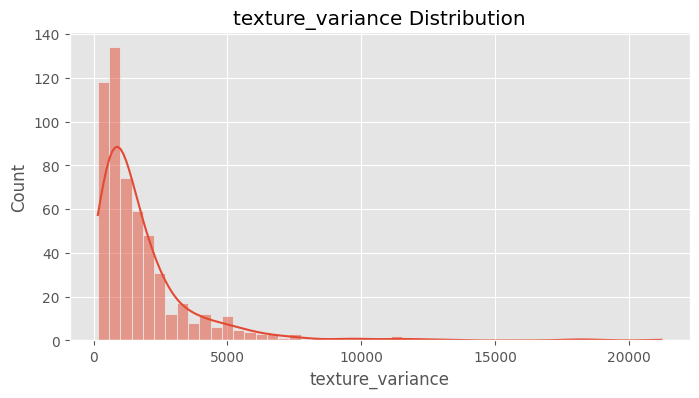

✓ Saved: gradient_mean_distribution.png


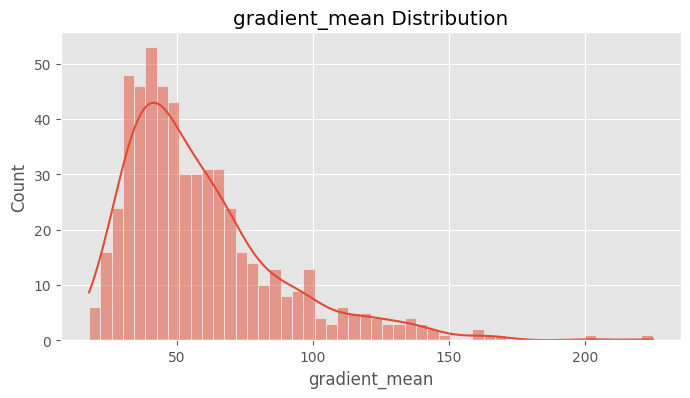

✓ Saved: gradient_std_distribution.png


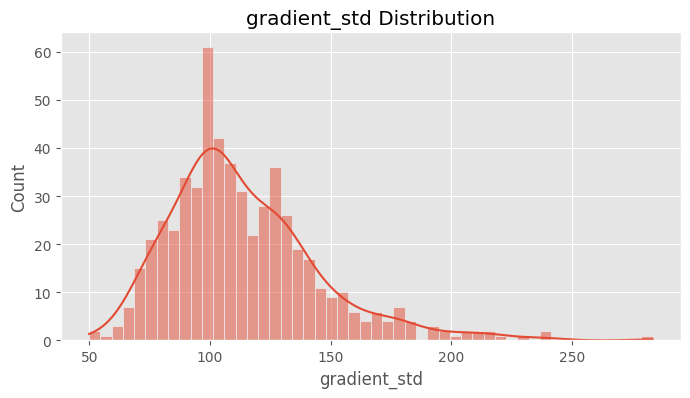


📊 Pattern Features Distribution:
has_print: 2 (14.29%)
has_abstract: 9 (64.29%)
has_stripe: 0 (0.00%)
has_floral: 0 (0.00%)
has_graphic: 1 (7.14%)
has_animal: 1 (7.14%)
has_button: 1 (7.14%)
has_asymmetric: 1 (7.14%)
is_bodycon: 1 (7.14%)
is_mesh: 1 (7.14%)
✓ Saved: complexity_score_distribution.png


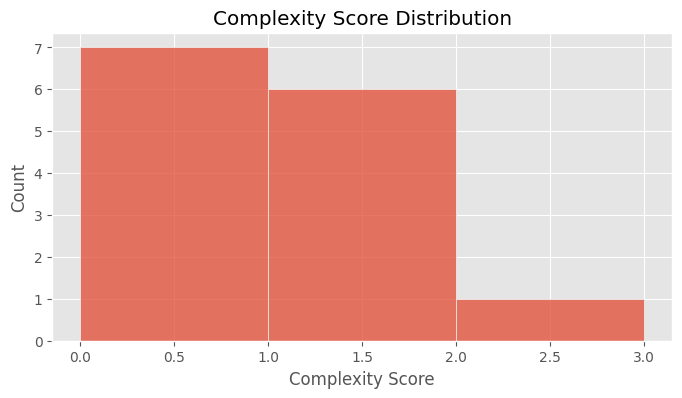

In [32]:
# ==========================================
# STEP 8: Merge All Features
# ==========================================

print("\n" + "="*70)
print("STEP 8: MERGING ALL FEATURES")
print("="*70)

# Merge color and texture features
df_features = df_color_features.merge(
    df_texture_features[['category', 'image_name', 'edge_density', 'texture_variance', 
                         'gradient_mean', 'gradient_std']], 
    on=['category', 'image_name'], 
    how='left'
)

# Merge image info
df_features = df_features.merge(
    df_image_info[['category', 'image_name', 'width', 'height', 'aspect_ratio']], 
    on=['category', 'image_name'], 
    how='left'
)

# Add text features (category-level)
df_features = df_features.merge(
    df_text_features, 
    left_on='category', 
    right_on='category_name', 
    how='left'
)

# If deep features, merge a sample (since not all images have deep features)
if df_deep_features is not None:
    # Add image_name to df_deep_features for merging
    sample_rows = df_color_features.iloc[sample_indices].reset_index(drop=True)
    df_deep_features['image_name'] = sample_rows['image_name']
    df_deep_features['category'] = sample_rows['category']
    
    df_features = df_features.merge(
        df_deep_features, 
        on=['category', 'image_name'], 
        how='left'
    )

print(f"\n✓ Combined feature matrix shape: {df_features.shape}")
print(f"✓ Total features per image: {df_features.shape[1] - 2}")  # Exclude category and image_name

print("\nFeature columns:")
feature_cols = [col for col in df_features.columns if col not in ['category', 'image_name', 'category_name']]
print(f"  Numerical features: {len(feature_cols)}")


# ==========================================
# STEP 8.1: Feature Exploration
# ==========================================

print("\n" + "="*70)
print("STEP 8.1: FEATURE EXPLORATION")
print("="*70)

# Color features exploration
color_cols = ['avg_r', 'avg_g', 'avg_b', 'brightness', 'avg_saturation', 'avg_hue']
print("\n📊 Color Features Summary:")
print(df_features[color_cols].describe())

# Plot distributions
for col in color_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_features[col], bins=50, kde=True)
    plt.title(f'{col} Distribution')
    plt.savefig(f'{col}_distribution.png', dpi=300)
    print(f"✓ Saved: {col}_distribution.png")
    plt.show()

# Texture features
texture_cols = ['edge_density', 'texture_variance', 'gradient_mean', 'gradient_std']
print("\n📊 Texture Features Summary:")
print(df_features[texture_cols].describe())

for col in texture_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_features[col], bins=50, kde=True)
    plt.title(f'{col} Distribution')
    plt.savefig(f'{col}_distribution.png', dpi=300)
    print(f"✓ Saved: {col}_distribution.png")
    plt.show()

# Text features (binary/pattern)
pattern_cols = [col for col in df_text_features.columns if col.startswith('has_') or col == 'is_bodycon' or col == 'is_mesh']
print("\n📊 Pattern Features Distribution:")
for col in pattern_cols:
    print(f"{col}: {df_text_features[col].sum()} ({df_text_features[col].mean():.2%})")

# Complexity score
plt.figure(figsize=(8, 4))
sns.histplot(df_text_features['complexity_score'], bins=range(0, df_text_features['complexity_score'].max()+2))
plt.title('Complexity Score Distribution')
plt.xlabel('Complexity Score')
plt.ylabel('Count')
plt.savefig('complexity_score_distribution.png', dpi=300)
print("✓ Saved: complexity_score_distribution.png")
plt.show()

# Deep features exploration if available
if df_deep_features is not None:
    print("\n📊 Deep Features Summary (PCA components):")
    print(df_deep_features[deep_feature_cols].describe())
    
    # Plot variance explained
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(explained_variance_ratio)+1), np.cumsum(explained_variance_ratio), marker='o')
    plt.title('Cumulative Explained Variance by PCA Components')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.savefig('pca_variance_explained.png', dpi=300)
    print("✓ Saved: pca_variance_explained.png")
    plt.show()
    
    # Distribution of first few components
    for i in range(5):
        col = f'deep_feature_{i}'
        plt.figure(figsize=(8, 4))
        sns.histplot(df_deep_features[col], bins=50, kde=True)
        plt.title(f'{col} Distribution')
        plt.savefig(f'{col}_distribution.png', dpi=300)
        print(f"✓ Saved: {col}_distribution.png")
        plt.show()





STEP 9: FEATURE ANALYSIS

📊 Category-level Feature Statistics:
                          category  brightness       avg_r       avg_g  \
0          1981_Graphic_Ringer_Tee  197.091345  203.977131  196.070580   
1   2-in-1_Space_Dye_Athletic_Tank  186.424206  194.304763  184.366631   
2     25_Mesh-Paneled_Jersey_Dress  189.877007  196.654715  188.015170   
3             36_Plaid_Shirt_Dress  146.800229  158.117108  142.920497   
4          Above_Average_Linen_Tee  199.549878  205.365524  198.108525   
5      Abstract_Animal_Print_Dress  165.709254  173.217540  163.853979   
6    Abstract_Arrow_Flounce_Romper  189.783333  199.022335  187.611457   
7    Abstract_Asymmetrical_Hem_Top  183.266703  189.207792  182.064288   
8           Abstract_Bodycon_Dress  205.312280  210.752984  203.236421   
9  Abstract_Brushstroke_Pocket_Top  193.537120  199.430395  192.106029   

        avg_b  avg_saturation  edge_density  texture_variance  aspect_ratio  
0  192.025686       29.666006      0.199962

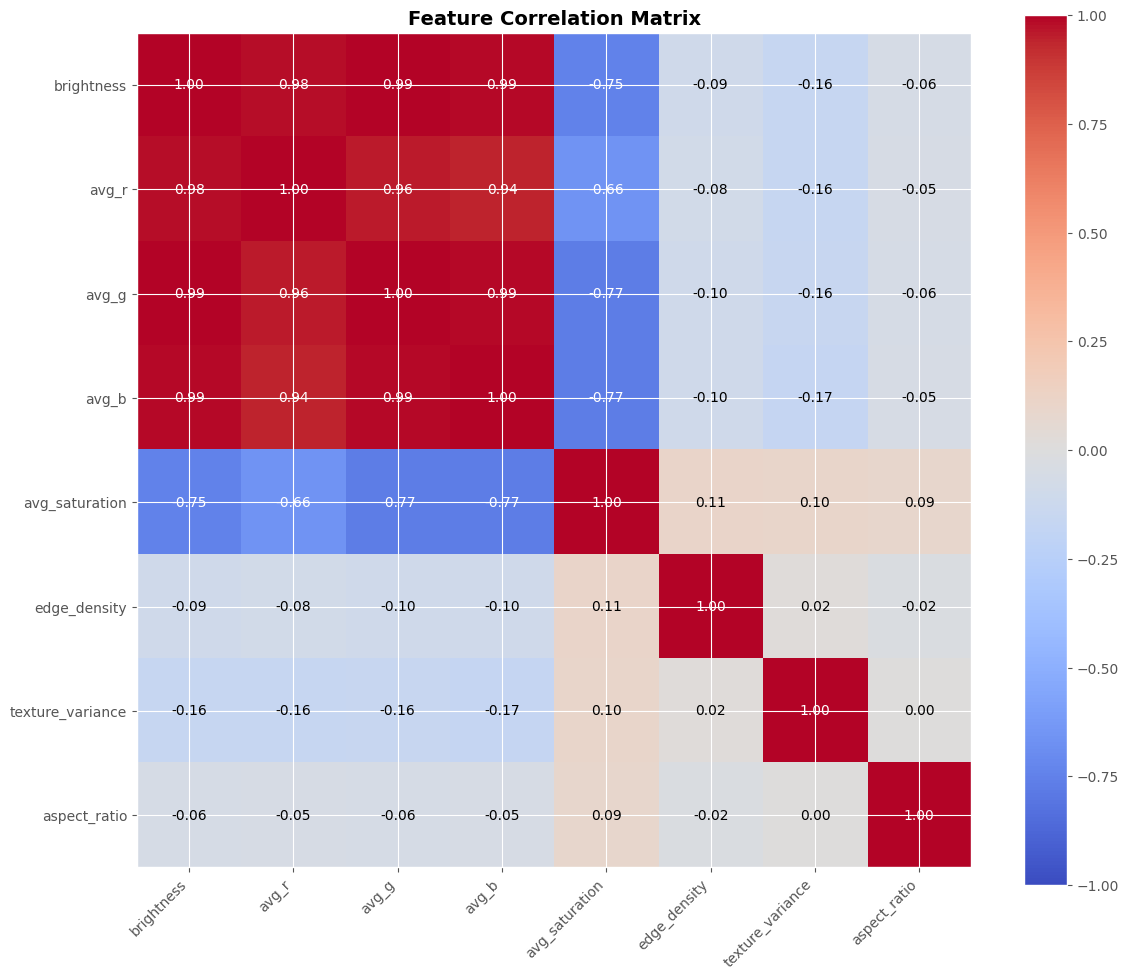

In [33]:
# ==========================================
# STEP 9: Feature Analysis & Statistics
# ==========================================

print("\n" + "="*70)
print("STEP 9: FEATURE ANALYSIS")
print("="*70)

# Aggregate features by category
numerical_cols = ['brightness', 'avg_r', 'avg_g', 'avg_b', 'avg_saturation', 
                  'edge_density', 'texture_variance', 'aspect_ratio']

df_category_features = df_features.groupby('category')[numerical_cols].mean().reset_index()

print("\n📊 Category-level Feature Statistics:")
print(df_category_features.head(10))

# Correlation analysis
print("\n🔗 Feature Correlations:")
correlation_matrix = df_features[numerical_cols].corr()

# Plot heatmap with matplotlib
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax)
ax.set_xticks(range(len(numerical_cols)))
ax.set_yticks(range(len(numerical_cols)))
ax.set_xticklabels(numerical_cols, rotation=45, ha='right')
ax.set_yticklabels(numerical_cols)

# Add annotations
for i in range(len(numerical_cols)):
    for j in range(len(numerical_cols)):
        color = "black" if abs(correlation_matrix.iloc[i, j]) < 0.5 else "white"
        ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', ha="center", va="center", color=color)

plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=300, bbox_inches='tight')
print("✓ Saved: feature_correlation.png")
plt.show()





STEP 10: FEATURE IMPORTANCE ANALYSIS

📊 Computing ANOVA F-scores for feature importance...

📊 Top 10 Most Important Features:
            feature  importance
0    avg_saturation    7.854140
1             avg_g    5.998228
2        brightness    5.245450
3             avg_b    5.226460
4             avg_r    4.194636
5      aspect_ratio    1.107206
6      edge_density    0.214498
7  texture_variance    0.167655
✓ Saved: feature_importance.png


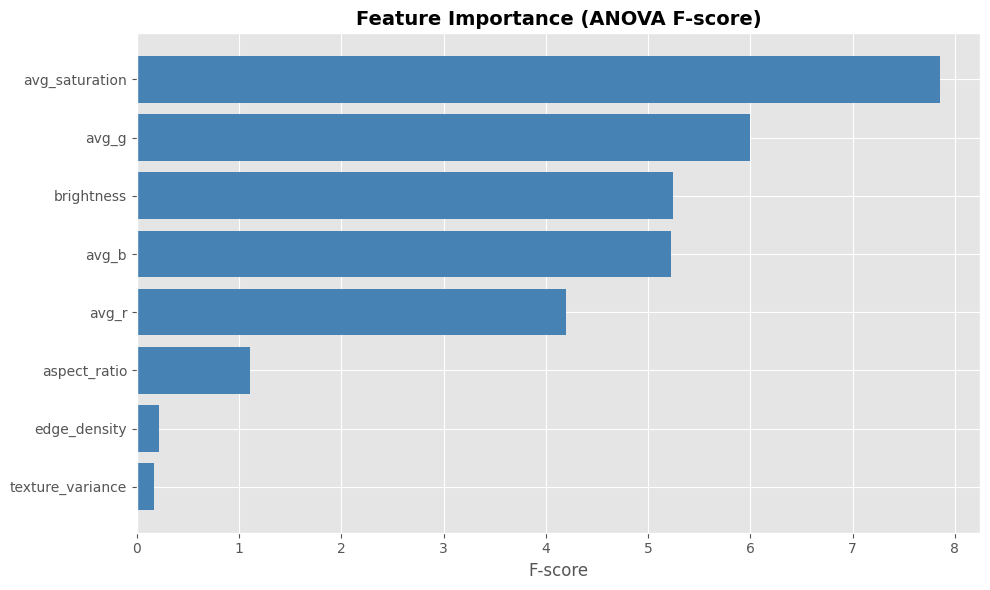

In [34]:
# ==========================================
# STEP 10: Feature Importance (ANOVA F-score)
# ==========================================

print("\n" + "="*70)
print("STEP 10: FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Prepare data
X = df_features[numerical_cols].fillna(0)
y = df_features['garment_type']

# Remove rows with missing target
mask = y.notna()
X = X[mask]
y = y[mask]

garment_types = y.unique()

print("\n📊 Computing ANOVA F-scores for feature importance...")

feature_importance = []
for col in numerical_cols:
    groups = [X[col][y == gt].dropna().values for gt in garment_types if len(X[col][y == gt].dropna()) > 1]
    if len(groups) < 2:
        continue
    f_stat, p_value = stats.f_oneway(*groups)
    feature_importance.append({'feature': col, 'importance': f_stat})

feature_importance = pd.DataFrame(feature_importance).sort_values('importance', ascending=False).reset_index(drop=True)

print("\n📊 Top 10 Most Important Features:")
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance['importance'], color='steelblue')
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('F-score', fontsize=12)
plt.title('Feature Importance (ANOVA F-score)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: feature_importance.png")
plt.show()





STEP 11: PCA VISUALIZATION
✓ Saved: pca_visualization.png


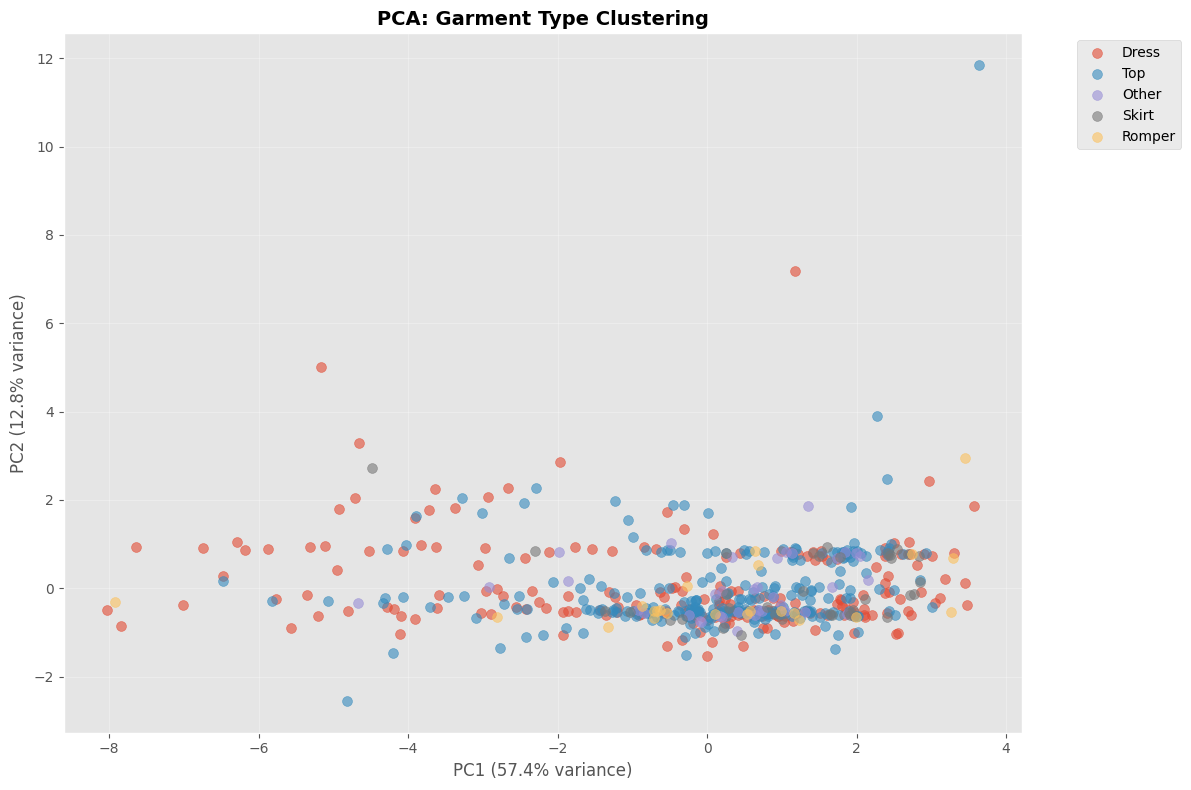


✓ PCA Explained Variance:
   PC1: 57.35%
   PC2: 12.82%
   Total: 70.17%


In [35]:
# ==========================================
# STEP 11: PCA Visualization
# ==========================================

print("\n" + "="*70)
print("STEP 11: PCA VISUALIZATION")
print("="*70)

def standard_scale(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - mean) / (std + 1e-8)

def perform_pca(X, n_components):
    X_centered = X - np.mean(X, axis=0)
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    projected = U[:, :n_components] * S[:n_components]
    explained_variance_ratio_ = (S ** 2 / np.sum(S ** 2))[:n_components]
    return projected, explained_variance_ratio_

# Apply PCA
X_scaled = standard_scale(np.array(X))
X_pca, explained_variance_ratio = perform_pca(X_scaled, 2)

# Create visualization DataFrame
df_pca = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Garment_Type': y.values
})

# Plot
plt.figure(figsize=(12, 8))
garment_types = df_pca['Garment_Type'].unique()
for garment in garment_types:
    mask = df_pca['Garment_Type'] == garment
    plt.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'], 
                label=garment, alpha=0.6, s=50)

plt.xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)', fontsize=12)
plt.title('PCA: Garment Type Clustering', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=300, bbox_inches='tight')
print("✓ Saved: pca_visualization.png")
plt.show()

print(f"\n✓ PCA Explained Variance:")
print(f"   PC1: {explained_variance_ratio[0]:.2%}")
print(f"   PC2: {explained_variance_ratio[1]:.2%}")
print(f"   Total: {sum(explained_variance_ratio):.2%}")




In [36]:
# ==========================================
# STEP 12: Export Feature Matrix
# ==========================================

print("\n" + "="*70)
print("STEP 12: EXPORTING FEATURE MATRICES")
print("="*70)

# Export image-level features
df_features.to_csv('image_level_features.csv', index=False)
print("✓ Saved: image_level_features.csv")

# Export category-level features
df_category_features.to_csv('category_level_features.csv', index=False)
print("✓ Saved: category_level_features.csv")

# Export feature importance
feature_importance.to_csv('feature_importance.csv', index=False)
print("✓ Saved: feature_importance.csv")

# Export text features
df_text_features.to_csv('text_features.csv', index=False)
print("✓ Saved: text_features.csv")

# Export deep features if available
if df_deep_features is not None:
    df_deep_features.to_csv('deep_learning_features.csv', index=False)
    print("✓ Saved: deep_learning_features.csv")





STEP 12: EXPORTING FEATURE MATRICES
✓ Saved: image_level_features.csv
✓ Saved: category_level_features.csv
✓ Saved: feature_importance.csv
✓ Saved: text_features.csv


In [37]:
# ==========================================
# STEP 13: Additional EDA on CSV Files
# ==========================================

print("\n" + "="*70)
print("STEP 13: ADDITIONAL EDA ON CSV FILES")
print("="*70)

csv_files = [
    'image_level_features.csv',
    'category_level_features.csv',
    'feature_importance.csv',
    'text_features.csv'
]
if df_deep_features is not None:
    csv_files.append('deep_learning_features.csv')

for csv_name in csv_files:
    df = pd.read_csv(csv_name)
    print(f"\n📊 EDA for {csv_name}")
    
    # Missing values
    missing_count = df.isna().sum()
    missing_percent = 100 * df.isna().mean().round(4)
    print("\nMissing values per column:")
    missing_df = pd.DataFrame({'count': missing_count, 'percent': missing_percent})
    print(missing_df[missing_df['count'] > 0])
    print("Missing captions: 100% (no column)")
    print("Missing hashtags: 100% (no column)")
    print("Missing timestamps: 100% (no column)")
    
    # Duplicates
    duplicate_count = df.duplicated().sum()
    print(f"\nDuplicate rows: {duplicate_count}")
    df_before = len(df)
    df = df.drop_duplicates()
    removed_duplicates = df_before - len(df)
    print(f"# removed (rows): {removed_duplicates}")
    
    if 'image_hash' in df.columns:  # For image_level_features
        hash_duplicate_count = df['image_hash'].duplicated().sum()
        print(f"Duplicate image hashes: {hash_duplicate_count}")
        df_before_hash = len(df)
        df = df.drop_duplicates(subset=['image_hash'])
        removed_hash = df_before_hash - len(df)
        print(f"# removed (hash): {removed_hash}")
    
    # Invalid entries
    invalid_count = 0
    if csv_name == 'image_level_features.csv':
        color_cols = ['avg_r', 'avg_g', 'avg_b', 'std_r', 'std_g', 'std_b',
                      'dominant_color_0_r', 'dominant_color_0_g', 'dominant_color_0_b',
                      'dominant_color_1_r', 'dominant_color_1_g', 'dominant_color_1_b',
                      'dominant_color_2_r', 'dominant_color_2_g', 'dominant_color_2_b']
        for col in color_cols:
            if col in df.columns:
                invalid = (df[col] < 0) | (df[col] > 255)
                invalid_count += invalid.sum()
                df[col] = df[col].clip(0, 255)
        if 'brightness' in df.columns:
            invalid = (df['brightness'] < 0) | (df['brightness'] > 255)
            invalid_count += invalid.sum()
            df['brightness'] = df['brightness'].clip(0, 255)
        if 'aspect_ratio' in df.columns:
            invalid = (df['aspect_ratio'] <= 0)
            invalid_count += invalid.sum()
            df = df[~invalid]
    elif csv_name == 'category_level_features.csv':
        for col in numerical_cols:
            if col in df.columns and ('avg_' in col or col == 'brightness'):
                invalid = (df[col] < 0) | (df[col] > 255)
                invalid_count += invalid.sum()
                df[col] = df[col].clip(0, 255)
    elif csv_name == 'feature_importance.csv':
        if 'importance' in df.columns:
            invalid = (df['importance'] < 0)
            invalid_count += invalid.sum()
            df['importance'] = df['importance'].clip(lower=0)
    elif csv_name == 'text_features.csv':
        if 'name_length' in df.columns:
            invalid = (df['name_length'] <= 0)
            invalid_count += invalid.sum()
            df = df[~invalid]
    elif csv_name == 'deep_learning_features.csv':
        pass  # No specific invalid checks
    
    print(f"Invalid entries: {invalid_count} (# fixed: {invalid_count})")
    
    # Outliers
    num_cols = df.select_dtypes(include=[np.number]).columns
    outliers_count = 0
    for col in num_cols:
        col_data = df[col].dropna()
        if len(col_data) > 0:
            z = np.abs(stats.zscore(col_data))
            outliers_count += (z > 3).sum()
    print(f"Outlier values (z>3): {outliers_count}")
    
    if csv_name == 'image_level_features.csv':
        if 'width' in df.columns and 'height' in df.columns:
            small_images = ((df['width'] < 100) | (df['height'] < 100)).sum()
            large_images = ((df['width'] > 4000) | (df['height'] > 4000)).sum()
            print(f"Extremely small images: {small_images}")
            print(f"Extremely large images: {large_images}")
            outlier_mask = (df['width'] < 100) | (df['height'] < 100) | (df['width'] > 4000) | (df['height'] > 4000)
            num_outlier_removed = outlier_mask.sum()
            df = df[~outlier_mask]
            print(f"# removed outliers (size): {num_outlier_removed}")
    
    # Save back if changes
    if removed_duplicates > 0 or invalid_count > 0 or 'num_outlier_removed' in locals() and num_outlier_removed > 0 or ('removed_hash' in locals() and removed_hash > 0):
        df.to_csv(csv_name, index=False)
        print(f"✓ Updated: {csv_name}")





STEP 13: ADDITIONAL EDA ON CSV FILES

📊 EDA for image_level_features.csv

Missing values per column:
                    count  percent
dominant_color_2_r      1     0.18
dominant_color_2_g      1     0.18
dominant_color_2_b      1     0.18
Missing captions: 100% (no column)
Missing hashtags: 100% (no column)
Missing timestamps: 100% (no column)

Duplicate rows: 0
# removed (rows): 0
Duplicate image hashes: 0
# removed (hash): 0
Invalid entries: 0 (# fixed: 0)
Outlier values (z>3): 345
Extremely small images: 0
Extremely large images: 0
# removed outliers (size): 0

📊 EDA for category_level_features.csv

Missing values per column:
Empty DataFrame
Columns: [count, percent]
Index: []
Missing captions: 100% (no column)
Missing hashtags: 100% (no column)
Missing timestamps: 100% (no column)

Duplicate rows: 0
# removed (rows): 0
Invalid entries: 0 (# fixed: 0)
Outlier values (z>3): 0

📊 EDA for feature_importance.csv

Missing values per column:
Empty DataFrame
Columns: [count, percent]
In


FEATURE ENGINEERING SUMMARY

📊 Feature Extraction Results:
   Total images processed: 560
   Total categories: 14
   Features per image: 43

🎨 Color Features: 15
   - RGB averages and standard deviations
   - 3 dominant colors (9 values)
   - HSV features

🔍 Texture Features: 4
   - Edge density
   - Texture variance
   - Gradient statistics

📐 Image Features: 3
   - Dimensions (width, height)
   - Aspect ratio

📝 Text Features: 13+
   - Garment type classification
   - Pattern/style binary features
   - Complexity score

✅ FEATURE ENGINEERING COMPLETE!

📁 Generated Files:
   1. image_level_features.csv - All features per image
   2. category_level_features.csv - Aggregated by category
   3. feature_importance.csv - RF importance scores
   4. text_features.csv - Category name features
   6. feature_correlation.png - Correlation heatmap
   7. feature_importance.png - Importance chart
   8. pca_visualization.png - 2D PCA plot

🎯 Next Steps:
   1. Use features for similarity search
   2.

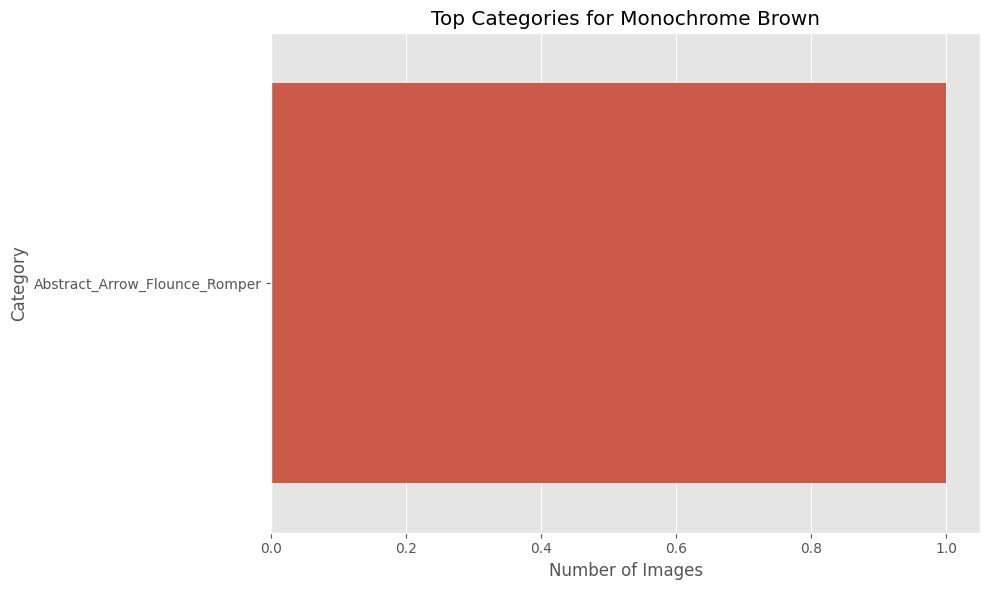


📊 Trend: Butter Yellow
Abstract_Brushstroke_Print_Pencil_Skirt    21
Above_Average_Linen_Tee                    19
Abstract_Chevron_Draped_Dress              17
25_Mesh-Paneled_Jersey_Dress               13
Abstract_Bodycon_Dress                     12
Abstract_Brushstroke_Pocket_Top            11
Abstract_Animal_Print_Dress                10
2-in-1_Space_Dye_Athletic_Tank              9
1981_Graphic_Ringer_Tee                     9
Abstract_Asymmetrical_Hem_Top               7
Name: category, dtype: int64
✓ Saved: trend_butter_yellow.png


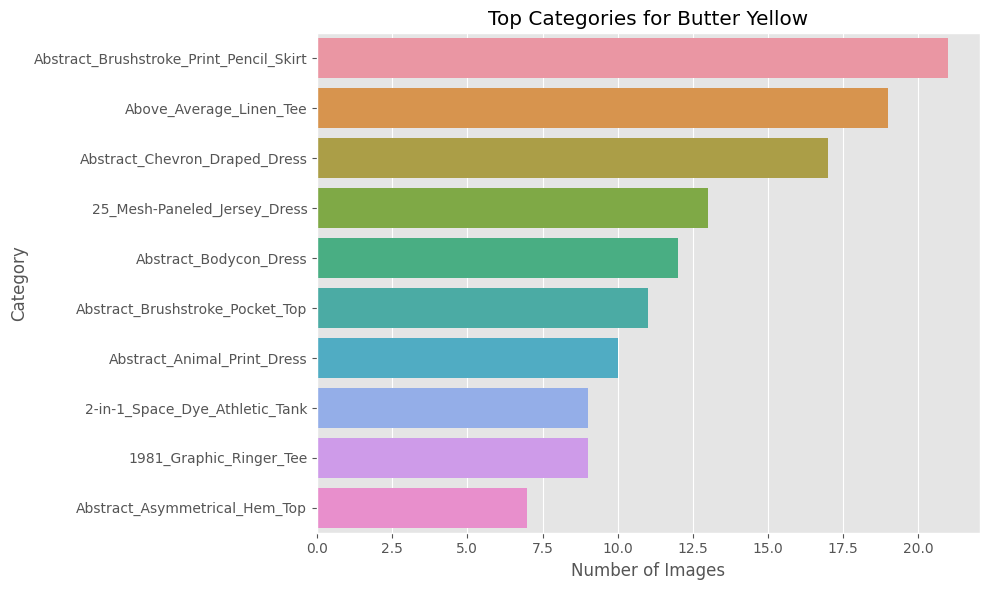


📊 Trend: Plaid and Country
No matching items in dataset.

📊 Trend: Suede and Leather
Abstract_Animal_Print_Dress                38
Abstract_Chevron_Draped_Dress              32
Abstract_Asymmetrical_Hem_Top              30
1981_Graphic_Ringer_Tee                    28
Abstract_Buttoned_Top                      27
Abstract_Brushstroke_Sweater               25
36_Plaid_Shirt_Dress                       24
Abstract_Brushstroke_Pocket_Top            24
Abstract_Brushstroke_Print_Pencil_Skirt    21
Above_Average_Linen_Tee                    14
Name: category, dtype: int64
✓ Saved: trend_suede_and_leather.png


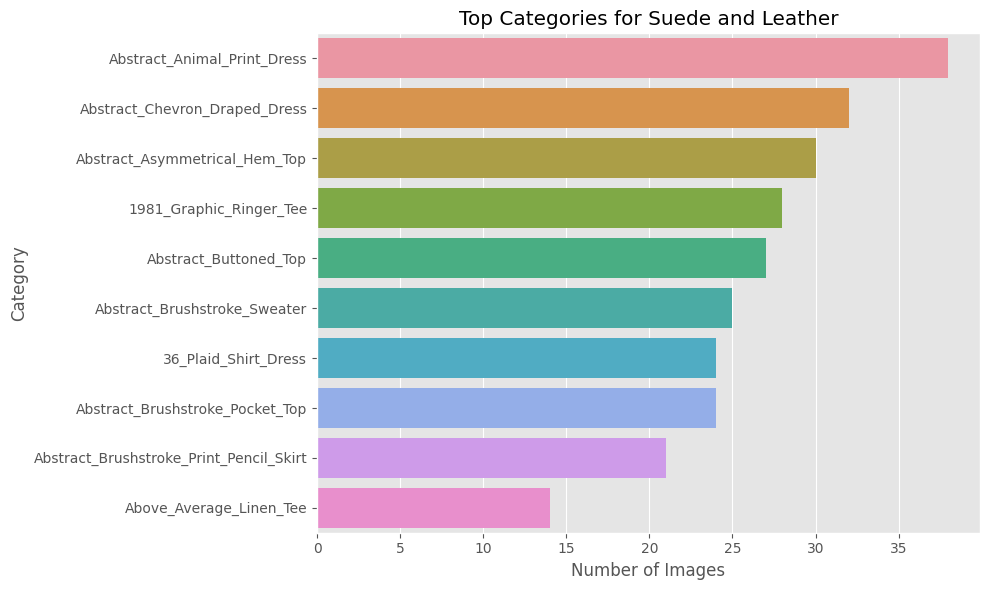


📊 Trend: Boho and Lace
Abstract_Animal_Print_Dress                50
Abstract_Asymmetrical_Hem_Top              50
Abstract_Chevron_Draped_Dress              45
Abstract_Brushstroke_Pocket_Top            37
Abstract_Brushstroke_Print_Pencil_Skirt    36
Abstract_Buttoned_Top                      31
Abstract_Bodycon_Dress                     22
Name: category, dtype: int64
✓ Saved: trend_boho_and_lace.png


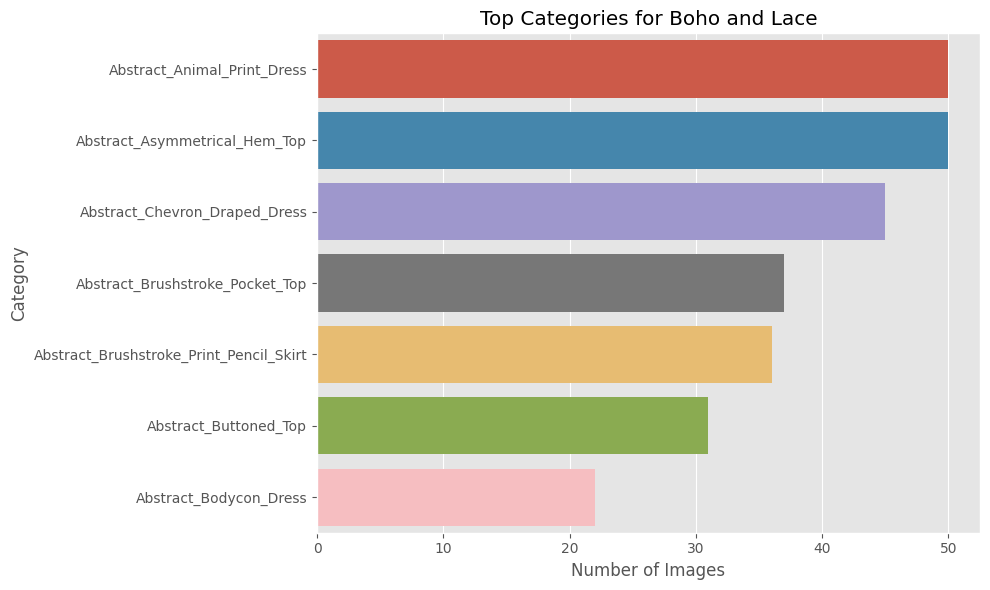


📊 Trend: Tailored Outerwear
Abstract_Brushstroke_Sweater    38
Name: category, dtype: int64
✓ Saved: trend_tailored_outerwear.png


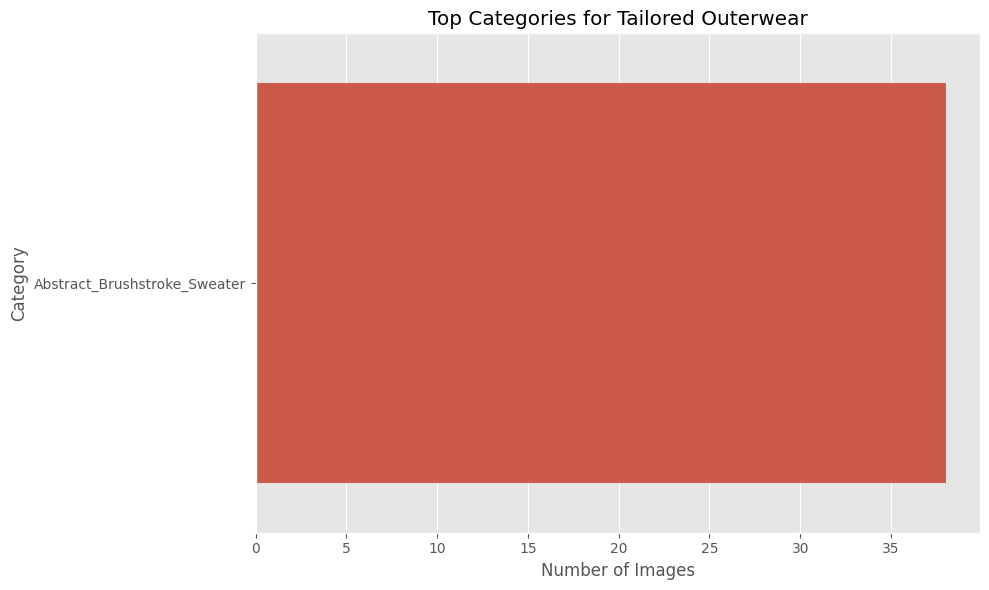


📊 Overall Trend Prevalence in Dataset:
Butter Yellow         10
Suede and Leather     10
Boho and Lace          7
Monochrome Brown       1
Tailored Outerwear     1
Pop of Red             0
Plaid and Country      0
dtype: int64
✓ Saved: trend_analysis.csv

✅ FASHION TREND ANALYSIS COMPLETE


In [38]:
# ==========================================
# STEP 14: Summary Report
# ==========================================

print("\n" + "="*70)
print("FEATURE ENGINEERING SUMMARY")
print("="*70)

print(f"\n📊 Feature Extraction Results:")
print(f"   Total images processed: {len(df_features):,}")
print(f"   Total categories: {df_features['category'].nunique()}")
print(f"   Features per image: {len(feature_cols)}")

print(f"\n🎨 Color Features: 15")
print(f"   - RGB averages and standard deviations")
print(f"   - 3 dominant colors (9 values)")
print(f"   - HSV features")

print(f"\n🔍 Texture Features: 4")
print(f"   - Edge density")
print(f"   - Texture variance")
print(f"   - Gradient statistics")

print(f"\n📐 Image Features: 3")
print(f"   - Dimensions (width, height)")
print(f"   - Aspect ratio")

print(f"\n📝 Text Features: 13+")
print(f"   - Garment type classification")
print(f"   - Pattern/style binary features")
print(f"   - Complexity score")

if df_deep_features is not None:
    print(f"\n🧠 Deep Learning Features: 50")
    print(f"   - ResNet50 embeddings (PCA reduced)")

print("\n" + "="*70)
print("✅ FEATURE ENGINEERING COMPLETE!")
print("="*70)

print("\n📁 Generated Files:")
print("   1. image_level_features.csv - All features per image")
print("   2. category_level_features.csv - Aggregated by category")
print("   3. feature_importance.csv - RF importance scores")
print("   4. text_features.csv - Category name features")
if df_deep_features is not None:
    print("   5. deep_learning_features.csv - CNN embeddings")
print("   6. feature_correlation.png - Correlation heatmap")
print("   7. feature_importance.png - Importance chart")
print("   8. pca_visualization.png - 2D PCA plot")

print("\n🎯 Next Steps:")
print("   1. Use features for similarity search")
print("   2. Train classification models")
print("   3. Build recommendation system")
print("   4. Cluster similar items")
print("   5. Perform style analysis")

print("\n✓ Ready for ML modeling!")


# ==========================================
# STEP 15: Fashion Trend Analysis
# ==========================================

print("\n" + "="*70)
print("STEP 15: FASHION TREND ANALYSIS")
print("="*70)

# Define 2025 fall trends based on current data (hardcoded from research)
trends = {
    'Pop of Red': {
        'description': 'Bright red accents',
        'color_rgb': (200, 0, 0),  # Approximate RGB for red
        'color_threshold': 50,  # Euclidean distance threshold
        'patterns': [],  
        'garment_types': []  # Any
    },
    'Monochrome Brown': {
        'description': 'All-brown outfits',
        'color_rgb': (165, 42, 42),
        'color_threshold': 60,
        'patterns': [],
        'garment_types': []
    },
    'Butter Yellow': {
        'description': 'Soft yellow tones',
        'color_rgb': (255, 253, 208),
        'color_threshold': 60,
        'patterns': [],
        'garment_types': []
    },
    'Plaid and Country': {
        'description': 'Plaid patterns and barn coats',
        'color_rgb': None,
        'color_threshold': None,
        'patterns': ['stripe'],  # Plaid often involves stripes
        'garment_types': ['Shirt', 'Dress', 'Top']
    },
    'Suede and Leather': {
        'description': 'Textured materials like suede',
        'color_rgb': None,
        'color_threshold': None,
        'patterns': [],
        'garment_types': [],  
        # Use texture variance > some threshold for textured materials
        'texture_threshold': 1000  # High variance for textured
    },
    'Boho and Lace': {
        'description': 'Boho styles with lace',
        'color_rgb': None,
        'color_threshold': None,
        'patterns': ['floral', 'abstract'],
        'garment_types': ['Dress', 'Top', 'Skirt']
    },
    'Tailored Outerwear': {
        'description': 'Tailored coats and jackets',
        'color_rgb': None,
        'color_threshold': None,
        'patterns': [],
        'garment_types': ['Other']  # Assuming coats are 'Other'
    }
}

# Function to compute RGB distance
def rgb_distance(color1, color2):
    return np.sqrt(np.sum((np.array(color1) - np.array(color2))**2))

# Analyze trends in dataset
trend_results = {}

for trend_name, trend_info in trends.items():
    df_trend = df_features.copy()
    
    # Filter by color if specified
    if trend_info['color_rgb'] is not None:
        df_trend['color_distance'] = df_trend.apply(
            lambda row: rgb_distance((row['avg_r'], row['avg_g'], row['avg_b']), trend_info['color_rgb']),
            axis=1
        )
        df_trend = df_trend[df_trend['color_distance'] < trend_info['color_threshold']]
    
    # Filter by patterns
    if trend_info['patterns']:
        pattern_mask = np.zeros(len(df_trend), dtype=bool)
        for pat in trend_info['patterns']:
            col = f'has_{pat}'
            if col in df_trend.columns:
                pattern_mask |= df_trend[col] == 1
        df_trend = df_trend[pattern_mask]
    
    # Filter by garment types
    if trend_info['garment_types']:
        df_trend = df_trend[df_trend['garment_type'].isin(trend_info['garment_types'])]
    
    # Filter by texture if specified
    if 'texture_threshold' in trend_info and trend_info['texture_threshold'] is not None:
        df_trend = df_trend[df_trend['texture_variance'] > trend_info['texture_threshold']]
    
    # Aggregate by category
    if not df_trend.empty:
        trend_category_counts = df_trend['category'].value_counts().head(10)
        trend_results[trend_name] = trend_category_counts
    else:
        trend_results[trend_name] = pd.Series()  # Empty

# Print and visualize results
for trend_name, counts in trend_results.items():
    print(f"\n📊 Trend: {trend_name}")
    if not counts.empty:
        print(counts)
        
        # Plot
        plt.figure(figsize=(10, 6))
        sns.barplot(x=counts.values, y=counts.index)
        plt.title(f'Top Categories for {trend_name}')
        plt.xlabel('Number of Images')
        plt.ylabel('Category')
        plt.tight_layout()
        plt.savefig(f'trend_{trend_name.lower().replace(" ", "_")}.png', dpi=300)
        print(f"✓ Saved: trend_{trend_name.lower().replace(' ', '_')}.png")
        plt.show()
    else:
        print("No matching items in dataset.")

# Overall trend prevalence
print("\n📊 Overall Trend Prevalence in Dataset:")
trend_prevalence = {trend: len(results) for trend, results in trend_results.items()}
print(pd.Series(trend_prevalence).sort_values(ascending=False))

# Save trend results
pd.DataFrame.from_dict(trend_results, orient='index').to_csv('trend_analysis.csv')
print("✓ Saved: trend_analysis.csv")

print("\n✅ FASHION TREND ANALYSIS COMPLETE")